In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel
import scipy.stats as stats
from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data
from source.autoencoder import AESurrogateModel
#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
import surr_on_real.epid_data as epd

%load_ext autoreload
%autoreload 2

pm.__version__  

'5.25.1'

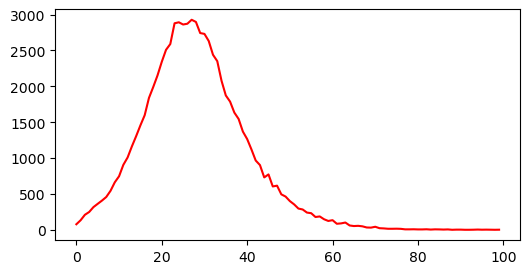

In [2]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

plt.plot(observed_data,color='red')

In [3]:
df_c = pd.read_excel('../network_hybrid_33/sum_intensity/data1990_2019.xlsx')
df_c = df_c[(df_c.cld_year >= 2009)&(df_c.cld_year < 2020)]

# qty_total - qty_15
# remove people older than 15, because children's data has less underreporting
df_c['qty_lt15'] = df_c['qty_total'] - df_c['qty_15']
df_c['wd_lt15'] = df_c['wd_total'] - df_c['wd_15']

# we combine [40w:52w] year x  AND  [0w:20w] year x+1
df_c = df_c[~((df_c.cld_year == 2009)&(df_c.week_number < 40))]
df_c = df_c[~((df_c.cld_year == 2019)&(df_c.week_number > 40))]
df_c = df_c[((df_c.week_number >= 40)|(df_c.week_number <= 39))]
df_c = df_c[['town_name','cld_year','week_number','qty_lt15','wd_lt15','qty_total','qty_15','wd_total','wd_15']]
df_c['years_part'] = ''
ntowns = df_c.town_name.nunique()
df_c = df_c[df_c.week_number!=53]
nweeks =  df_c.week_number.nunique()

for i in np.arange(2009,2019):
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
df_c.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,yp_week
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,1.0
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,2.0
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,3.0
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,4.0
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,5.0


In [5]:
df_c[(df_c.town_name=='Самара')&(df_c.years_part=='20172018')].shape

(52, 11)

<Axes: xlabel='yp_week', ylabel='wd_total'>

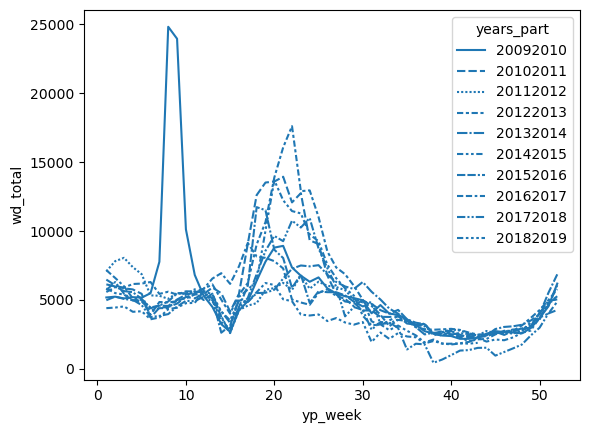

In [6]:
plt.subplots(1,1,figsize=(5,3))
sns.lineplot(x = df_c[df_c.town_name=='Самара'].yp_week,
            y = df_c[df_c.town_name=='Самара'].wd_total, 
             style=df_c[df_c.town_name=='Самара'].years_part)

In [7]:
pcr = pd.read_csv('surr_on_real/ПЦР_Самара_Челябинск_Волгоград_Спб_18_11_2024.csv', 
            sep=';', header=1).iloc[1:,:7]
pcr_table_from_excel_to_python = {
    "date": "Дата",
    "tested_total": "Число образцов тестированных на грипп",
    "tested_strain_0": "A (субтип не определен)",
    "tested_strain_1": "A(H1)pdm09",
    "tested_strain_2": "A(H3)",
    "tested_strain_3": "B",
}
pcr.head(2)

,Unnamed: 0,Unnamed: 1,Число образцов тестированных на грипп,A (субтип не определен),A(H1)pdm09,A(H3),B
1,2010.1 (04.01.2010 - 10.01.2010),Н,0,0,0,0,0
2,2010.2 (11.01.2010 - 17.01.2010),Н,46,0,3,0,0


In [8]:
from datetime import datetime
myDate = "2017 40"
datetime.strptime(myDate + ' 1', "%Y %W %w")

datetime.datetime(2017, 10, 2, 0, 0)

In [25]:
myDate = "2018 40"
datetime.strptime(myDate + ' 0', "%Y %W %w")

datetime.datetime(2018, 10, 7, 0, 0)

In [39]:
myDate = "2019 40"
datetime.strptime(myDate + ' 0', "%Y %W %w")

datetime.datetime(2019, 10, 13, 0, 0)

In [13]:


epid = epd.EpidData(city = '', path='surr_on_real/', 
                    start_time='',end_time='')

In [14]:
epid_df = epid.cases_df.loc[:, ['date', 'sars_total_cases','total_population', 
 'datetime', 'rel_strain_0',
       'real_cases_strain_0', 'rel_strain_1', 'real_cases_strain_1',
       'rel_strain_2', 'real_cases_strain_2', 'rel_strain_3',
       'real_cases_strain_3']]
epid_df = epid_df[epid_df.datetime<'2020-01-01']
epid_df[['cld_year', 'week_number']] = \
    epid_df.apply(lambda x: [int(x.date[:4]), int(x.date[5:].split()[0])], 
              axis=1,result_type='expand')

epid_df.loc[:,epid_df.columns.str.contains('real')]=\
epid_df.loc[:,epid_df.columns.str.contains('real')].fillna(0)

# и так нет
epid_df = epid_df[epid_df.week_number!=53]
nweeks =  epid_df.week_number.nunique()
ntowns = 1

for i in np.arange(2010,2019):
    epid_df.loc[((epid_df.cld_year == i)&(epid_df.week_number >=40)
             )|((epid_df.cld_year == i+1)&(epid_df.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    epid_df.loc[((epid_df.cld_year == i)&(epid_df.week_number >=40)
             )|((epid_df.cld_year == i+1)&(epid_df.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
    
epid_df.iloc[50:55]

,date,sars_total_cases,total_population,datetime,rel_strain_0,real_cases_strain_0,rel_strain_1,real_cases_strain_1,rel_strain_2,real_cases_strain_2,rel_strain_3,real_cases_strain_3,cld_year,week_number,years_part,yp_week
50,2010.51 (20.12.2010 - 26.12.2010),5901,1161112,2010-12-20,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2010,51,20102011,12.0
51,2010.52 (27.12.2010 - 02.01.2011),5489,1161522,2010-12-27,0.0,0.0,0.000000,0.0,0.0,0.0,0.021277,117.0,2010,52,20102011,13.0
52,2011.1 (03.01.2011 - 09.01.2011),4156,1161522,2011-01-03,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2011,1,20102011,14.0
53,2011.2 (10.01.2011 - 16.01.2011),5438,1161522,2011-01-10,0.0,0.0,0.040000,218.0,0.0,0.0,0.080000,435.0,2011,2,20102011,15.0
54,2011.3 (17.01.2011 - 23.01.2011),9081,1161522,2011-01-17,0.0,0.0,0.037736,343.0,0.0,0.0,0.188679,1713.0,2011,3,20102011,16.0


In [21]:
0.065217 * 4240

276.52008

<Axes: xlabel='yp_week', ylabel='real_cases_strain_1'>

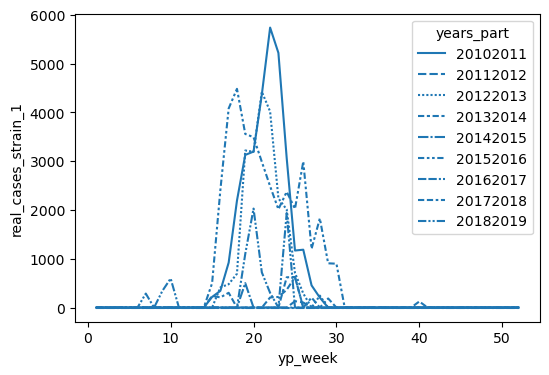

In [6]:
plt.subplots(1,1,figsize=(6,4))
sns.lineplot(x = epid_df.yp_week,
            y = epid_df.real_cases_strain_1, 
             style=epid_df.years_part)

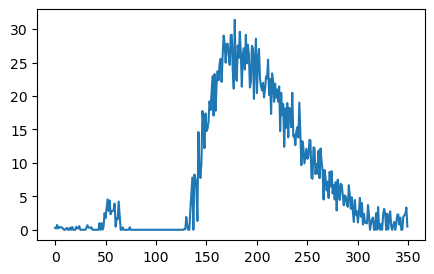

In [134]:
plt.subplots(1,1,figsize=(5,3))
model = AESurrogateModel(10**5, 'sw')
q = model.simulate(0.005,0.87)
q[q<0] = 0
plt.plot(q)

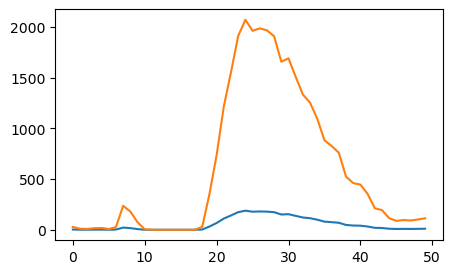

In [133]:
plt.subplots(1,1,figsize=(5,3))
kk = pd.Series(q).groupby(pd.Series(q).index // 7).sum() 
plt.plot(kk)
plt.plot(kk*11)

In [111]:
pd.Series(q).groupby(pd.Series(q).index // 7).sum().values.shape

(50,)

In [15]:
def surr_sim(rng, alpha, beta, modeling_duration, 
             pop, n_nodes, top, koeff,
            size=None):
    modeling_duration = modeling_duration[0]
    pop = pop[0]
    n_nodes =n_nodes[0]
    top =top[0]
    koeff = koeff[0]
    
    if top:
        top_str = 'ba'
    else:
        top_str = 'sw'
    model = AESurrogateModel(10**5, top_str)
    #alpha, beta
    q = model.simulate(alpha,beta)
    
    q[q<0] = 0
    week_data = pd.Series(q).groupby(pd.Series(q).index // 7).sum().values
    
    diff_w = week_data.shape[0] - modeling_duration
    # если меньше -- добавляем нули
    if diff_w < 0:
        week_data = [*week_data,*[0]*abs(diff_w)]
    else:
        week_data = week_data[abs(diff_w):]#week_data[:modeling_duration]
        
    return ([i*koeff for i in week_data])

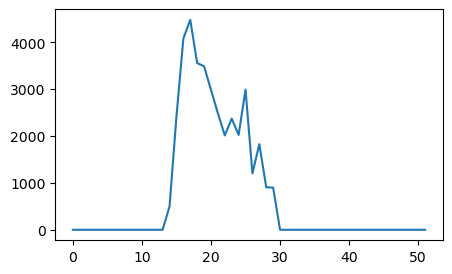

In [55]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2015
pop = epid_df.total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [56]:
ax.get_xticks()[1:]

array([ 0., 10., 20., 30., 40., 50., 60.])

In [88]:
def calibr(draws=200, chains = 4, epsilon=500, 
           incidence=[], koeff = [1]):
    progressbar = True

    gamma = [0.3]
    delta=[0.2]
    n_nodes=[100000]
    top = [False] #is BA?
    #koeff = [int(pop/ n_nodes)]
    modeling_duration = [incidence.shape[0]]

    new_observed = incidence

    with pm.Model() as pm_modelp:
        real_data = pm.Data("incidence", new_observed)
        alpha = pm.Uniform(name="alpha", lower=10/n_nodes[0], upper=1.)
        beta = pm.Uniform(name="tau", lower=0., upper=1.)

        # вынесем, тк для прогноза нужно будет задавать размер

        sim = pm.Simulator("sim", surr_sim, 
                            params = (alpha, beta, 
                                      modeling_duration, 
                                      [pop], n_nodes, top, koeff
                                     ),   

                            epsilon=epsilon, 
                            #ndims_params=[1,1,1,1,1,1],
                            observed=new_observed
                          )

        # maybe parameter start == mean of HM ?
        #step=pm.DEMetropolisZ()

        start_time = time.time()
        idatap = pm.sample_smc(#tune=tune, 
                              draws=draws, 
            chains=chains,
                              #step=step, 
            return_inferencedata=True,
                              progressbar=progressbar)
        end_time = time.time()
        idatap.extend(pm.sample_posterior_predictive(idatap, 
                                                     progressbar=progressbar))

    # It took  32616.331862449646 sec
    print('It took ', end_time-start_time, 'sec')


    idata = idatap.copy()

    idata.sample_stats = idata.sample_stats.drop('beta')
    idata.sample_stats = idata.sample_stats.drop('log_marginal_likelihood')
    idata.sample_stats = idata.sample_stats.drop('accept_rate')
    idata.to_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")

In [92]:
(pop/n_nodes)[0]

np.float64(11.744460959692898)

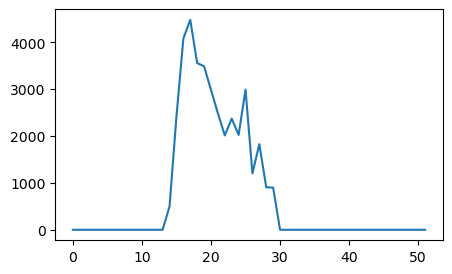

In [131]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2015
pop = epid_df[(epid_df.years_part==f'{year}{year+1}')].total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [132]:
koeff = [(pop/n_nodes)[0]]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence, 
       koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  58.009713649749756 sec



0.08009597518180624 0.016052013313431708
[0]


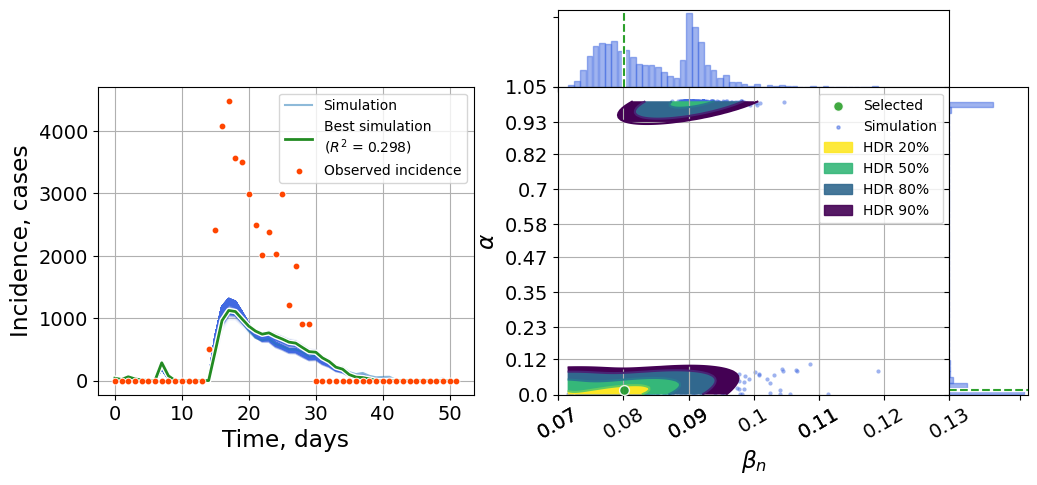

In [134]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)

In [135]:
koeff = [1]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence, 
       koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Sampling: [sim]


It took  42.40132975578308 sec



0.6294320169435395 0.5079947170464468
[0]


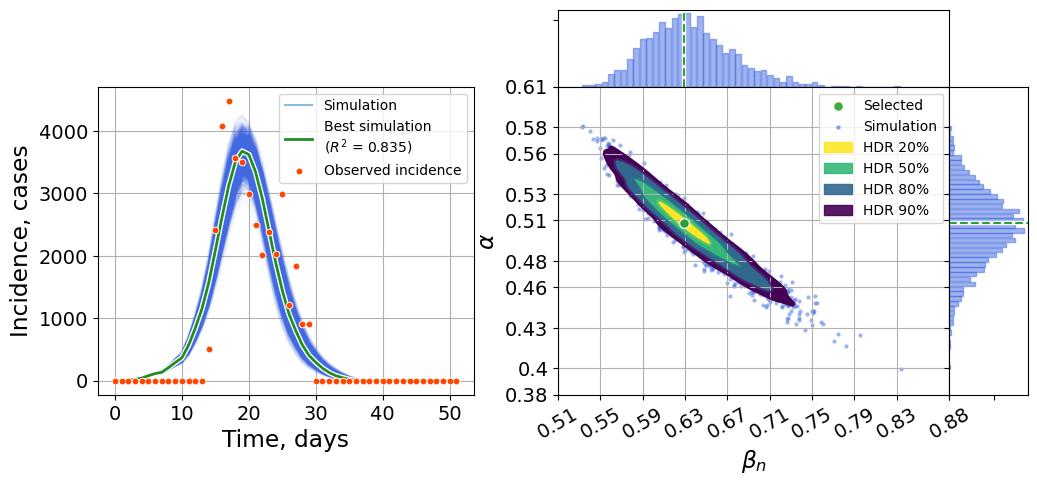

In [137]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)

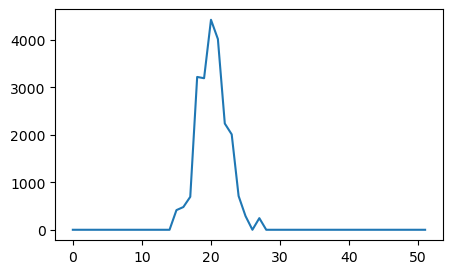

In [138]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2012
pop = epid_df[(epid_df.years_part==f'{year}{year+1}')].total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [139]:
koeff = [1]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence,
      koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Sampling: [sim]


It took  41.33688426017761 sec



0.8430599182858058 0.38391456021112674
[0]


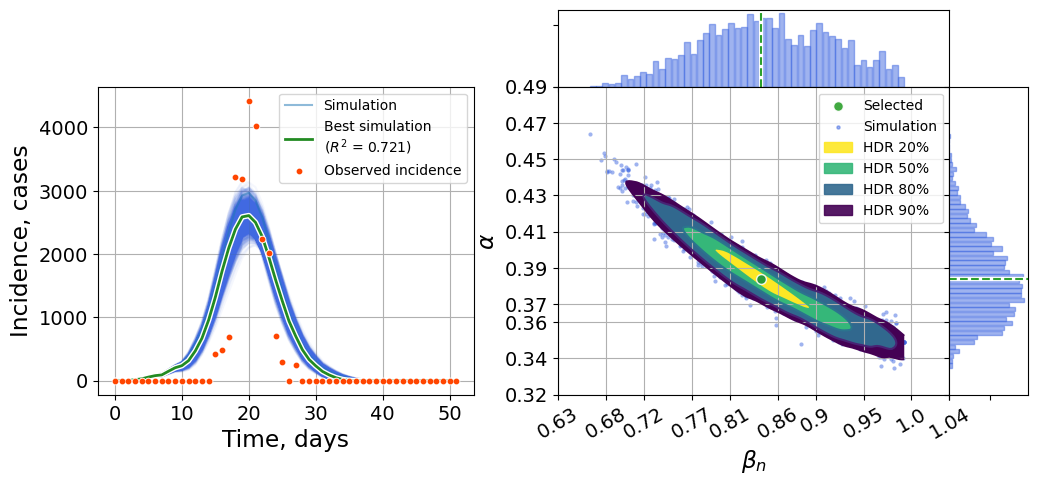

In [141]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)

In [142]:
koeff = [(pop/n_nodes)[0]]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence,
      koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  54.65354537963867 sec



0.08361463639665581 0.01801724949592674
[0]


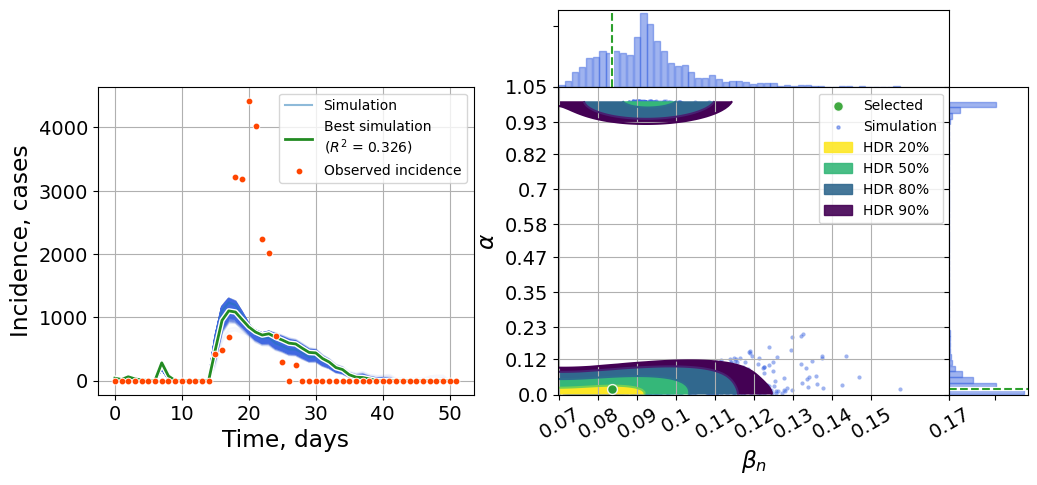

In [144]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)